In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables
file_name= 'income.csv'
random_state = 42

np.random.seed(random_state)

df= pd.read_csv(file_name)
df.head()

,Unnamed: 0,Territorio,NC_ - 0,NC_ 0- 10,NC_ 10- 15,NC_ 15- 26,NC_ 26- 55,NC_ 55- 75,NC_ 75-120,NC_120-inf,Income_tot
0,0,Abano Terme,0.0,3641.0,1997.0,4567.0,3268.0,413.0,400.0,177.0,347774542.0
1,1,Abbadia Cerreto,0.0,50.0,29.0,73.0,41.0,0.0,0.0,0.0,3399810.0
2,2,Abbadia Lariana,0.0,511.0,276.0,792.0,656.0,78.0,48.0,31.0,59153455.0
3,3,Abbadia San Salvatore,0.0,1303.0,783.0,1820.0,754.0,69.0,33.0,13.0,87615654.0
4,4,Abbasanta,0.0,577.0,194.0,443.0,430.0,26.0,13.0,0.0,30992769.0


### drop the columns that are not relevant for the clustering operation, if any, and explain why you do that

In [12]:
df1=df.drop(["Unnamed: 0","Territorio"], axis=1)

df1.head()

,NC_ - 0,NC_ 0- 10,NC_ 10- 15,NC_ 15- 26,NC_ 26- 55,NC_ 55- 75,NC_ 75-120,NC_120-inf,Income_tot
0,0.0,3641.0,1997.0,4567.0,3268.0,413.0,400.0,177.0,347774542.0
1,0.0,50.0,29.0,73.0,41.0,0.0,0.0,0.0,3399810.0
2,0.0,511.0,276.0,792.0,656.0,78.0,48.0,31.0,59153455.0
3,0.0,1303.0,783.0,1820.0,754.0,69.0,33.0,13.0,87615654.0
4,0.0,577.0,194.0,443.0,430.0,26.0,13.0,0.0,30992769.0


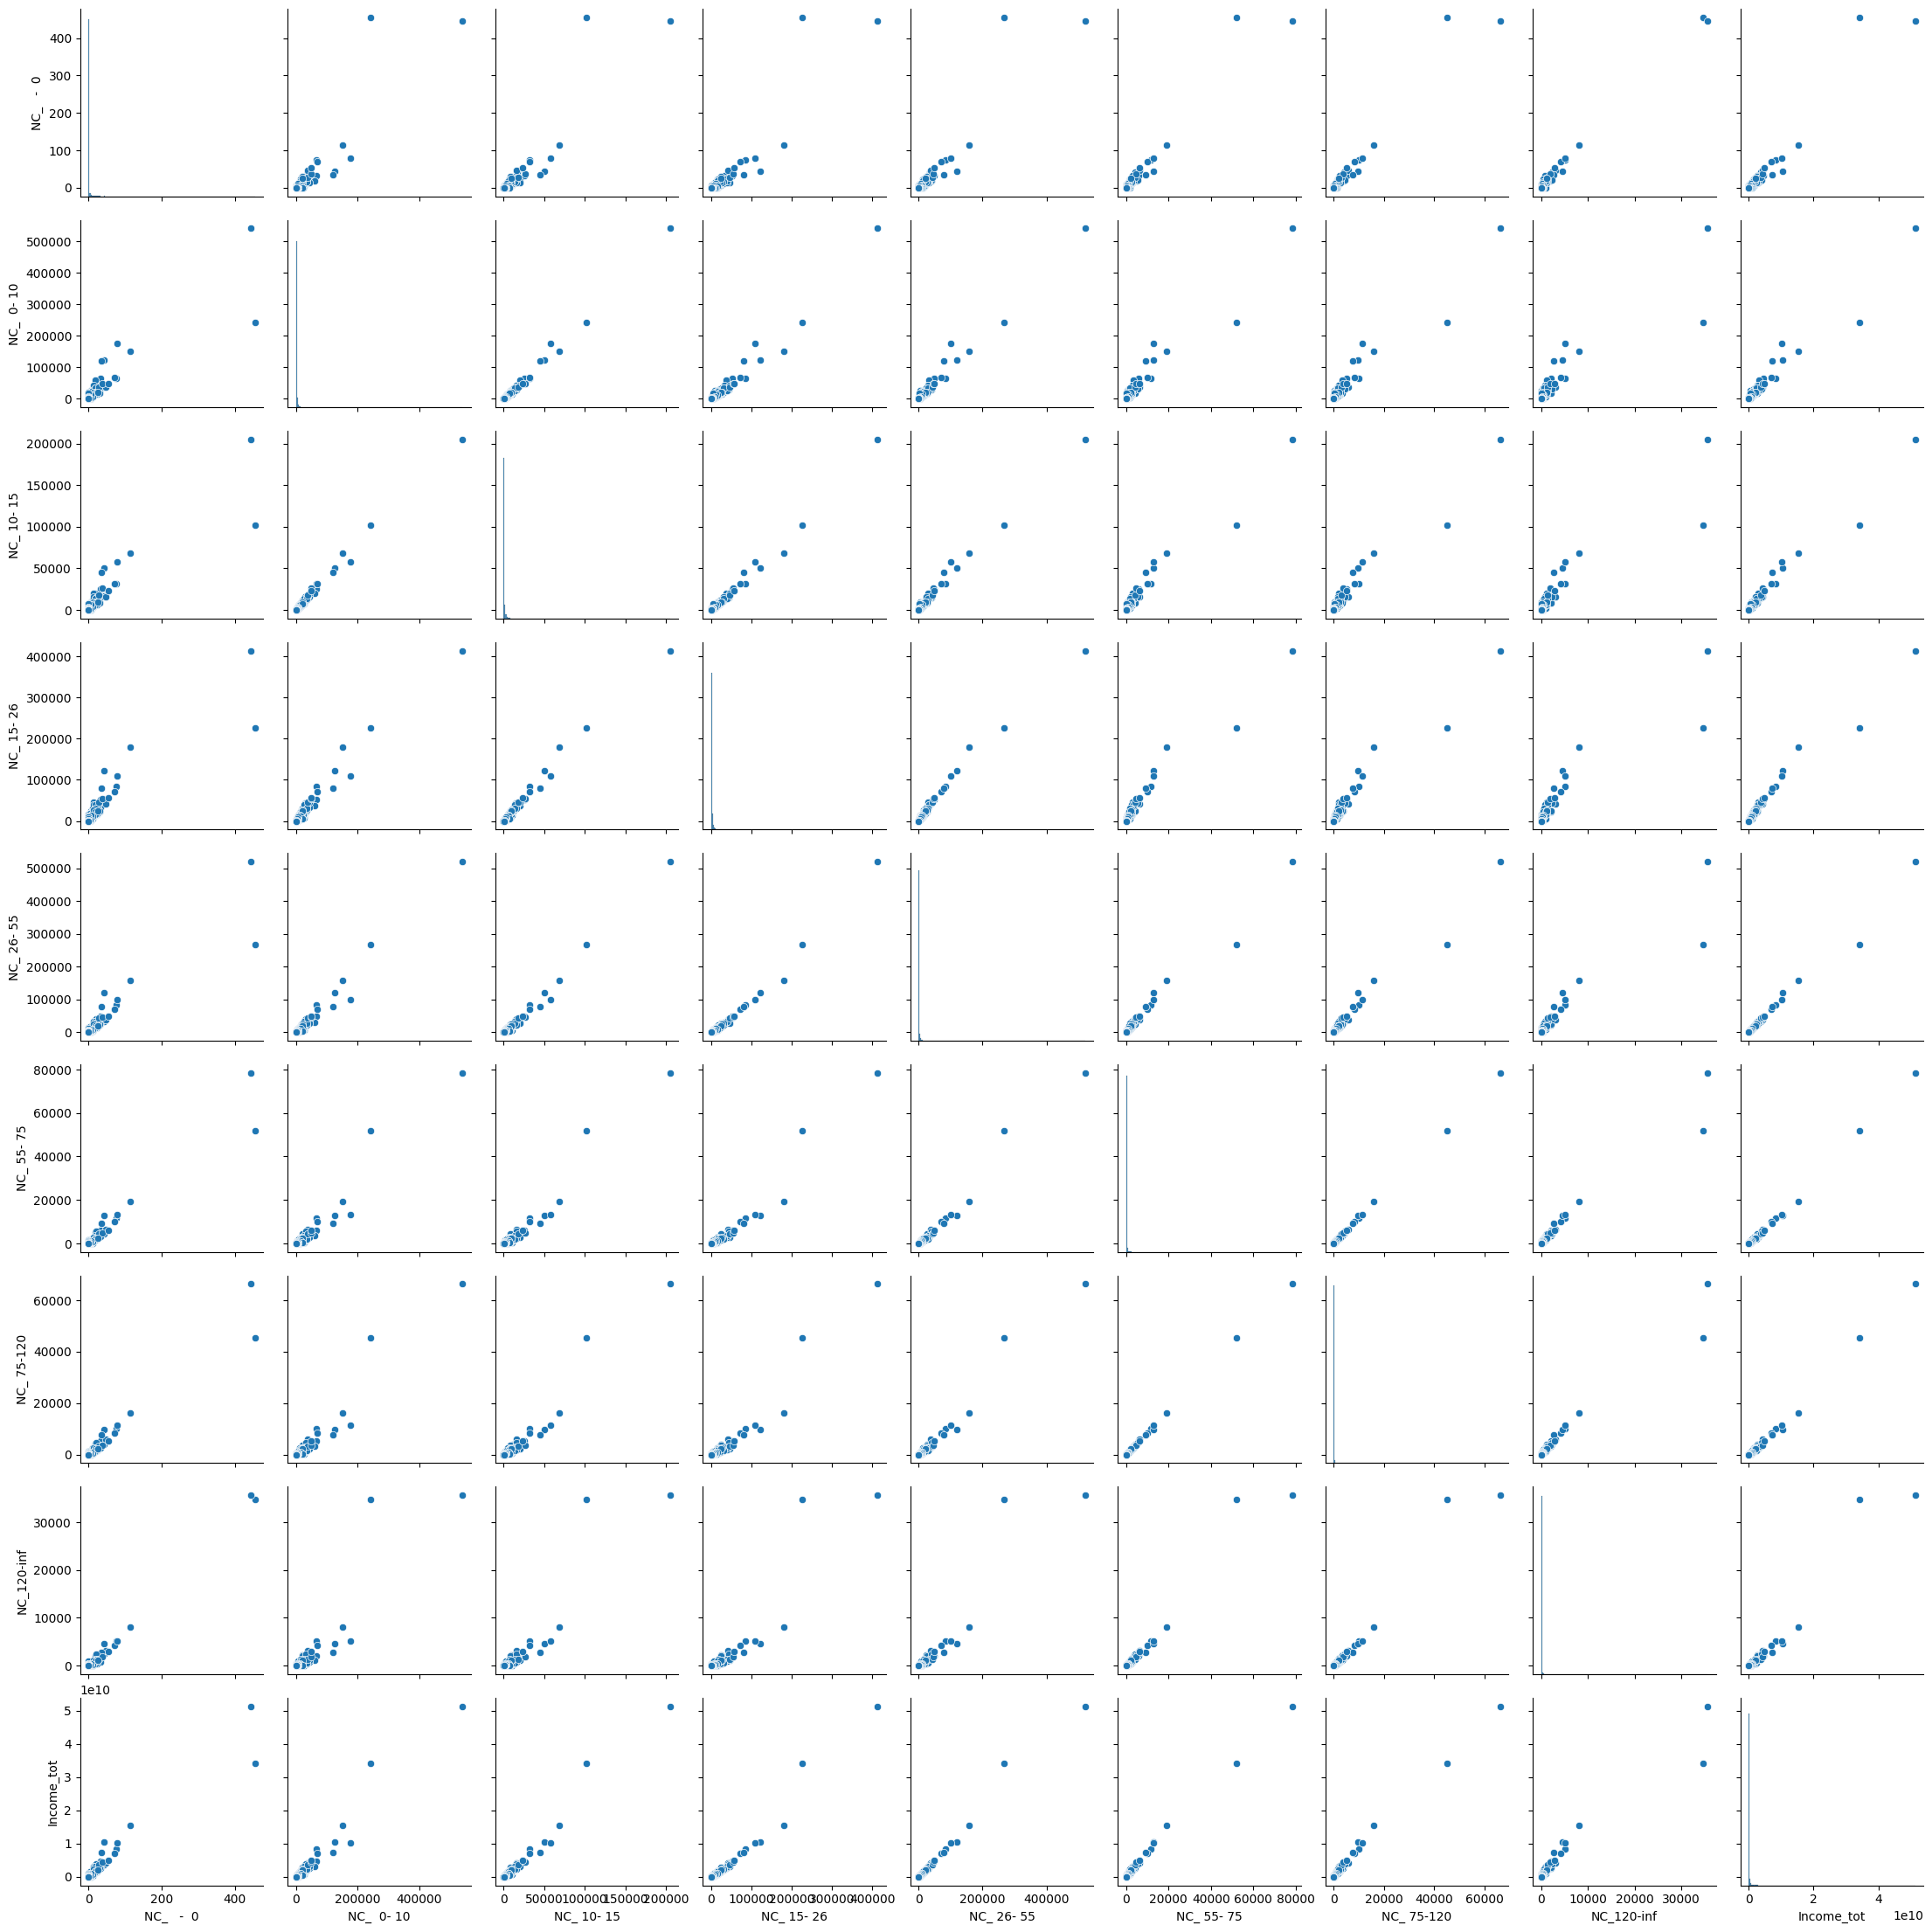

In [13]:
sns.pairplot(df1)

<Axes: >

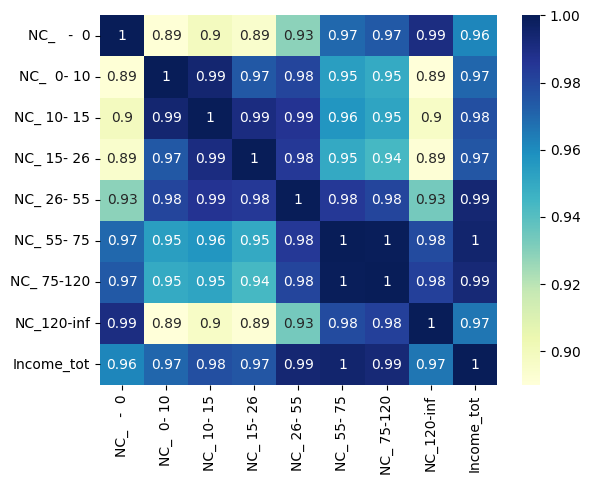

In [14]:
correlation_matrix = df1.corr()
sns.heatmap(correlation_matrix, cmap="YlGnBu", annot=True)

Dropping Income_tot and  NC_ 55- 75 because they have almost maximum correlation with other features

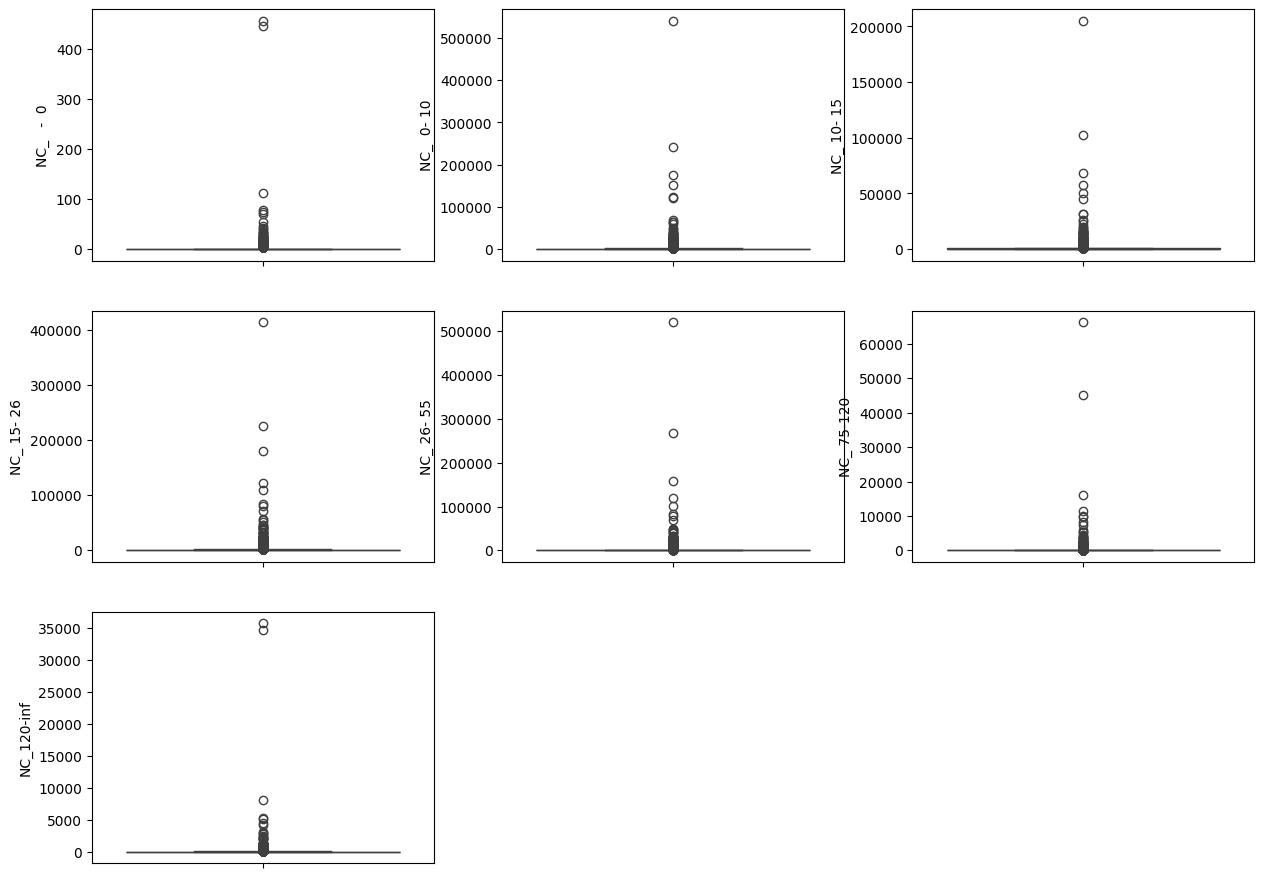

In [22]:
df1=df1.drop(['NC_ 55- 75', 'Income_tot'],axis=1)
plt.figure(figsize=(15,15))
pos = 1
for i in df1.columns:
        if(type(df1[i][0]) != str):
                plt.subplot(4, 3, pos)
                sns.boxplot(df1[i])
                pos += 1

###  find the best clustering scheme and compute: a) the quality indexes usual for clustering and b) the size of the clusters

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of possible clusters
k_range = range(2,11)

# Distortion, Silhouette Score and size deviation as measures
distortions = []
silhouette_scores = []
size_deviation = []

for i in k_range:

    # Iterate over our range of possible clusters
    km = KMeans(n_clusters = i,
                init = 'k-means++',
                n_init = 10,
                max_iter = 300,
                random_state = random_state)

    # Fit predict
    y_km = km.fit_predict(df1)

    # Compute the deviation with the provided formula
    deviation = np.sqrt(np.unique(y_km, return_counts = True)[1].var())/i

    # Store the data in the arrays
    distortions.append(km.inertia_)
    silhouette_scores.append(silhouette_score(df1,y_km))
    size_deviation.append(deviation)
    print("Number of clusters = {}\t- Distortion = {:6.2f}\t- Silhouette score = {:4.2f}"\
    .format(i,distortions[k_range.index(i)],silhouette_scores[k_range.index(i)]))

Number of clusters = 2	- Distortion = 578430590824.84	- Silhouette score = 0.99
Number of clusters = 3	- Distortion = 279187763270.82	- Silhouette score = 0.99
Number of clusters = 4	- Distortion = 157834832120.18	- Silhouette score = 0.93
Number of clusters = 5	- Distortion = 105625312318.63	- Silhouette score = 0.86
Number of clusters = 6	- Distortion = 70638656456.83	- Silhouette score = 0.86
Number of clusters = 7	- Distortion = 51535373283.50	- Silhouette score = 0.75
Number of clusters = 8	- Distortion = 39384307582.25	- Silhouette score = 0.70
Number of clusters = 9	- Distortion = 30740098038.10	- Silhouette score = 0.69
Number of clusters = 10	- Distortion = 25813219204.37	- Silhouette score = 0.69


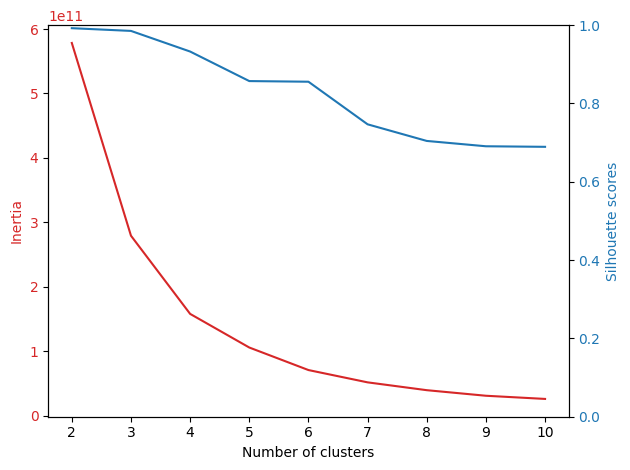

In [30]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(k_range, distortions, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Silhouette scores', color=color)  # we already handled the x-label with ax1
ax2.plot(k_range, silhouette_scores, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0,1) # the axis for silhouette is [0,1]

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

With DBSCAN:

In [37]:
from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid

# !!! ATTENZIONE alla distanza tra i punti !!!
# param_grid = {'eps': list(np.arange(0.01, 1, 0.01)), 'min_samples': list(range(1,10,1))}
param_grid = {'eps': list(np.arange(60, 120, 20)), 'min_samples': list(range(5,30,5))}
params = list(ParameterGrid(param_grid))

dbscan_out = pd.DataFrame(columns = ['eps','min_samples','n_clusters', 'size deviation index','silhouette', 'unclust%'])        #0 righe, 5 colonne

for i in range(len(params)):
    db = DBSCAN(**(params[i]))
    y_db = db.fit_predict(df1)
                                                                            #prende valori e filtra rumore
    cluster_labels_all = np.unique(y_db)
    cluster_labels = cluster_labels_all[cluster_labels_all != -1]
    n_clusters = len(cluster_labels)

    if n_clusters > 1:
        X_cl = df1.iloc[y_db!=-1,:]                                                #filtra il rumore da X
        y_db_cl = y_db[y_db!=-1]                                            #filtra il rumore da Y

        silhouette = silhouette_score(X_cl,y_db_cl)
        deviation = np.sqrt(np.unique(y_db_cl, return_counts = True)[1].var())/i
        uncl_p = (1 - y_db_cl.shape[0]/y_db.shape[0]) * 100                 #% di dati unclustered
        dbscan_out.loc[len(dbscan_out)] = [db.eps, db.min_samples, n_clusters, deviation, silhouette, uncl_p]
        print("{:11.2f}\t{:11}\t{:11}\t{:11.2f}\t{:11.2f}\t{:11.2f}".format(db.eps, db.min_samples, n_clusters, silhouette, uncl_p, 0))

C:\Users\giasa\AppData\Local\Temp\ipykernel_12616\1050731598.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  deviation = np.sqrt(np.unique(y_db_cl, return_counts = True)[1].var())/i


      60.00	          5	         21	       0.23	      40.91	       0.00
      60.00	         15	          3	       0.41	      49.75	       0.00
      60.00	         20	          4	       0.28	      52.38	       0.00
      60.00	         25	          2	       0.49	      54.80	       0.00
      80.00	          5	         24	       0.17	      32.80	       0.00
      80.00	         10	          2	       0.59	      38.55	       0.00
      80.00	         15	          3	       0.35	      42.07	       0.00
     100.00	          5	         19	       0.03	      26.54	       0.00
     100.00	         10	          7	       0.56	      31.91	       0.00
     100.00	         15	          4	       0.54	      34.98	       0.00
     100.00	         25	          2	       0.56	      39.84	       0.00


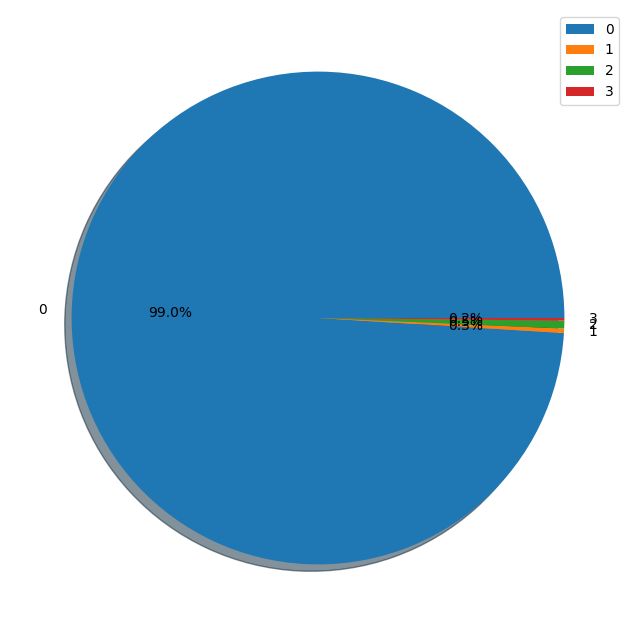

In [40]:
db = DBSCAN(eps = 100.00, min_samples = 15)

# Fit and predict
y_db = db.fit_predict(df1.to_numpy())
y_db_cl = y_db[y_db!=-1]                                            #filtra il rumore da Y

clust_sizes_km = np.unique(y_db_cl, return_counts=True)

fig = plt.figure(figsize=(16,8))
data = clust_sizes_km[1]
labels = clust_sizes_km[0]
plt.pie(data,
    labels = labels,
    autopct='%1.1f%%',
    shadow=True)
plt.legend()
plt.show()

###  apply a data transformation using the preprocessor below

In [41]:
from sklearn.preprocessing import PowerTransformer, \
StandardScaler
from sklearn.pipeline import make_pipeline
preprocessor = make_pipeline(
StandardScaler(with_std=False),
PowerTransformer(standardize=True),
)


In [42]:
X_fit= df1.copy()
X_fit= preprocessor.fit_transform(X_fit)
X_fit

array([[-0.18458481,  1.42250056,  1.45416407, ...,  1.52629428,
         1.9040105 ,  1.95368599],
       [-0.18458481, -1.19815717, -1.2034217 , ..., -1.03548671,
        -0.96755779, -0.85185344],
       [-0.18458481, -0.3045096 , -0.16628161, ...,  0.44620933,
         0.75114639,  1.32039823],
       ...,
       [-0.18458481, -0.05978469, -0.16232812, ..., -0.65745361,
        -0.76467497, -0.85185344],
       [-0.18458481, -0.60812915, -0.62665358, ..., -0.9807136 ,
        -0.80486123, -0.85185344],
       [-0.18458481, -0.06158195, -0.48954108, ..., -0.92360001,
        -0.96755779, -0.85185344]], shape=(7891, 7))

###  find the best clustering scheme for the transformed data, as done in step 3

In [54]:
from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid

# !!! ATTENZIONE alla distanza tra i punti !!!
# param_grid = {'eps': list(np.arange(0.01, 1, 0.01)), 'min_samples': list(range(1,10,1))}
param_grid = {'eps': list(np.arange(1, 4, 1)), 'min_samples': list(range(2,18,8))}
params = list(ParameterGrid(param_grid))

dbscan_out = pd.DataFrame(columns = ['eps','min_samples','n_clusters', 'size deviation index','silhouette', 'unclust%'])        #0 righe, 5 colonne

for i in range(len(params)):
    db = DBSCAN(**(params[i]))
    y_db = db.fit_predict(X_fit)
                                                                            #prende valori e filtra rumore
    cluster_labels_all = np.unique(y_db)
    cluster_labels = cluster_labels_all[cluster_labels_all != -1]
    n_clusters = len(cluster_labels)

    if n_clusters > 1:
        X_cl = df1.iloc[y_db!=-1,:]                                                #filtra il rumore da X
        y_db_cl = y_db[y_db!=-1]                                            #filtra il rumore da Y

        silhouette = silhouette_score(X_cl,y_db_cl)
        deviation = np.sqrt(np.unique(y_db_cl, return_counts = True)[1].var())/i
        uncl_p = (1 - y_db_cl.shape[0]/y_db.shape[0]) * 100                 #% di dati unclustered
        dbscan_out.loc[len(dbscan_out)] = [db.eps, db.min_samples, n_clusters, deviation, silhouette, uncl_p]
        print("{:11.2f}\t{:11}\t{:11}\t{:11.2f}\t{:11.2f}\t{:11.2f}".format(db.eps, db.min_samples, n_clusters, silhouette, uncl_p, 0))
        

C:\Users\giasa\AppData\Local\Temp\ipykernel_12616\3835286052.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  deviation = np.sqrt(np.unique(y_db_cl, return_counts = True)[1].var())/i


       1.00	          2	          5	      -0.19	       0.14	       0.00
       1.00	         10	          2	       0.85	       0.25	       0.00
       2.00	          2	          3	       0.85	       0.05	       0.00
       2.00	         10	          2	       0.85	       0.11	       0.00
       3.00	          2	          2	       0.86	       0.04	       0.00
       3.00	         10	          2	       0.86	       0.06	       0.00


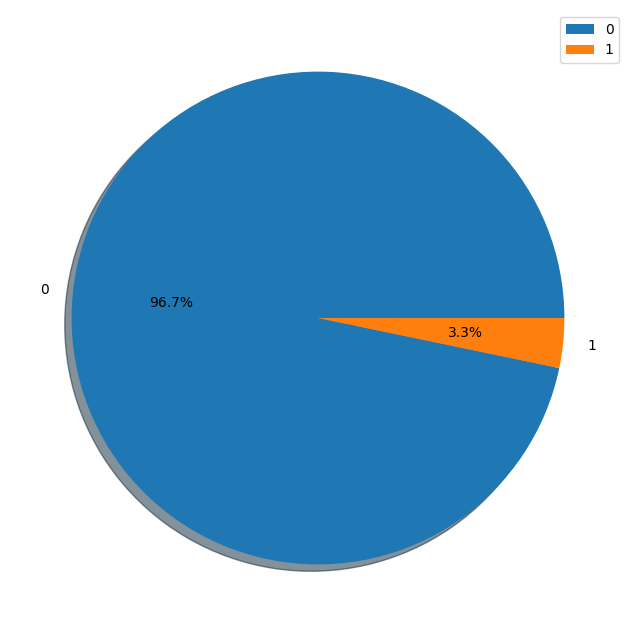

In [56]:
db = DBSCAN(eps = 3.00, min_samples = 2)

# Fit and predict
y_db = db.fit_predict(X_fit)
y_db_cl = y_db[y_db!=-1]                                            #filtra il rumore da Y

clust_sizes_km = np.unique(y_db_cl, return_counts=True)

fig = plt.figure(figsize=(16,8))
data = clust_sizes_km[1]
labels = clust_sizes_km[0]
plt.pie(data,
    labels = labels,
    autopct='%1.1f%%',
    shadow=True)
plt.legend()
plt.show()

In [46]:
# Range of possible clusters
k_range = range(2,11)

# Distortion, Silhouette Score and size deviation as measures
distortions = []
silhouette_scores = []
size_deviation = []

for i in k_range:

    # Iterate over our range of possible clusters
    km = KMeans(n_clusters = i,
                init = 'k-means++',
                n_init = 10,
                max_iter = 300,
                random_state = random_state)

    # Fit predict
    y_km = km.fit_predict(X_fit)

    # Compute the deviation with the provided formula
    deviation = np.sqrt(np.unique(y_km, return_counts = True)[1].var())/i

    # Store the data in the arrays
    distortions.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_fit,y_km))
    size_deviation.append(deviation)
    print("Number of clusters = {}\t- Distortion = {:6.2f}\t- Silhouette score = {:4.2f}"\
    .format(i,distortions[k_range.index(i)],silhouette_scores[k_range.index(i)]))

Number of clusters = 2	- Distortion = 578430590824.84	- Silhouette score = 0.99
Number of clusters = 3	- Distortion = 279187763270.82	- Silhouette score = 0.99
Number of clusters = 4	- Distortion = 157834832120.18	- Silhouette score = 0.93
Number of clusters = 5	- Distortion = 105625312318.63	- Silhouette score = 0.86
Number of clusters = 6	- Distortion = 70638656456.83	- Silhouette score = 0.86
Number of clusters = 7	- Distortion = 51535373283.50	- Silhouette score = 0.75
Number of clusters = 8	- Distortion = 39384307582.25	- Silhouette score = 0.70
Number of clusters = 9	- Distortion = 30740098038.10	- Silhouette score = 0.69
Number of clusters = 10	- Distortion = 25813219204.37	- Silhouette score = 0.69


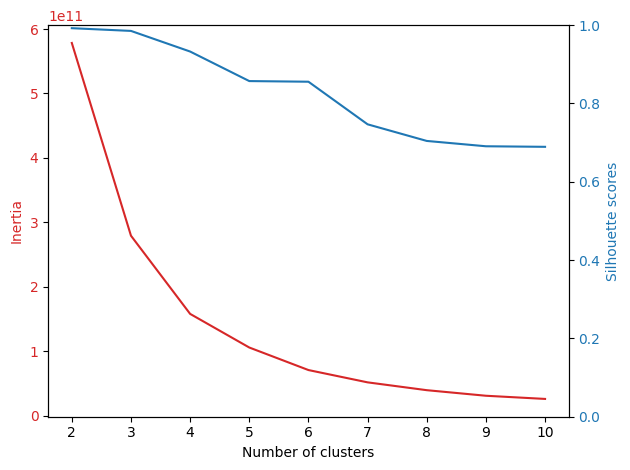

In [58]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(k_range, distortions, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Silhouette scores', color=color)  # we already handled the x-label with ax1
ax2.plot(k_range, silhouette_scores, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0,1) # the axis for silhouette is [0,1]

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

### . show together the results of the two clustering schemes obtained and comment which of the two is better and why

THE SECOND IS BETTER (KMEANS) BEACAUSE OF THE LOWER DISTORSION